# Minimal Bot Testbed -- Numeric Forecasting

Self-contained notebook replicating the bot's numeric forecasting pipeline without `forecasting-tools`.
Serves as a testbed to experiment with new forecasting approaches.

**Pipeline:** Question Input -> LLM Prompting (x6) -> Scenario Parsing -> Majority Vote -> Probit Aggregation -> CDF -> Visualization

## Update Procedure

When bot code changes upstream, sync these components:

| Component | Source File | Lines |
|---|---|---|
| Numeric prompt | `main.py` | 663-741 |
| Bounds messages | `main.py` | 1146-1175 |
| MultiScenarioPrediction | `main.py` | 48-54 |
| Majority vote validation | `main.py` | 827-895 |
| Ensure strictly increasing | `main.py` | 989-1046 |
| Probit z-spline | `dre_forecasting_tools.py` | 42-71 |
| Probit aggregate | `dre_forecasting_tools.py` | 312-402 |
| Percentile model | `main_with_no_framework.py` | 673-689 |
| NumericDefaults | `main_with_no_framework.py` | 650-670 |
| NumericDistribution + CDF | `main_with_no_framework.py` | 692-1125 |
| API fetch pattern | `main_with_no_framework.py` | 238-251 |

Also check model names in `main.py` bottom `llms` dict.

Upstream repos:
- `github.com/Metaculus/metac-bot-template`
- `github.com/Metaculus/forecasting-tools`

In [1]:
import os
import json
import asyncio
from datetime import datetime
from collections import Counter

import requests
import numpy as np
from scipy.integrate import quad
from scipy.interpolate import splrep, splev
from scipy.stats import linregress
import matplotlib.pyplot as plt
from pydantic import BaseModel, Field, model_validator
import nest_asyncio
from openai import AsyncOpenAI

nest_asyncio.apply()

# --- LLM Configuration (match main.py llms dict) ---
DEFAULT_MODEL = "openai/gpt-5.2"       # temperature=1
PARSER_MODEL = "openai/o4-mini"

client = AsyncOpenAI(
    base_url="https://openrouter.ai/api/v1",
    api_key=os.environ["OPENROUTER_API_KEY"],
)

print("OpenRouter client initialized.")
print(f"Default model: {DEFAULT_MODEL}")
print(f"Parser model:  {PARSER_MODEL}")

OpenRouter client initialized.
Default model: openai/gpt-5.2
Parser model:  openai/o4-mini


In [2]:
# =====================================================
# CELL 4: Fetch Question Data from Metaculus API
# =====================================================

POST_ID = 41752  # <-- Set your numeric question post ID here

METACULUS_TOKEN = os.environ["METACULUS_BOT_API_TOKEN"]
url = f"https://www.metaculus.com/api/posts/{POST_ID}/"
response = requests.get(url, headers={"Authorization": f"Token {METACULUS_TOKEN}"})
response.raise_for_status()
post_details = response.json()

q = post_details["question"]
scaling = q.get("scaling", {}) or {}

question = {
    "title": q["title"],
    "description": q.get("description", "") or "",
    "resolution_criteria": q.get("resolution_criteria", "") or "",
    "fine_print": q.get("fine_print", "") or "",
    "type": q["type"],
    "unit": q.get("label", "") or "",
    "range_min": scaling.get("range_min"),
    "range_max": scaling.get("range_max"),
    "zero_point": scaling.get("zero_point"),
    "open_upper_bound": q.get("open_upper_bound", True),
    "open_lower_bound": q.get("open_lower_bound", True),
}

# Parse bounds as floats
question["range_min"] = float(question["range_min"]) if question["range_min"] is not None else None
question["range_max"] = float(question["range_max"]) if question["range_max"] is not None else None
question["zero_point"] = float(question["zero_point"]) if question["zero_point"] is not None else None

# Build bound messages (from main.py:1146-1175)
lower_bound = question["range_min"]
upper_bound = question["range_max"]
unit = question["unit"]

if question["open_upper_bound"]:
    upper_bound_message = f"The question creator thinks the number is likely not higher than {upper_bound} {unit}."
else:
    upper_bound_message = f"The outcome can not be higher than {upper_bound} {unit}."

if question["open_lower_bound"]:
    lower_bound_message = f"The question creator thinks the number is likely not lower than {lower_bound} {unit}."
else:
    lower_bound_message = f"The outcome can not be lower than {lower_bound} {unit}."

print(f"Title: {question['title']}")
print(f"Type: {question['type']}")
print(f"Unit: {question['unit']}")
print(f"Range: [{lower_bound}, {upper_bound}]")
print(f"Zero point: {question['zero_point']}")
print(f"Open bounds: lower={question['open_lower_bound']}, upper={question['open_upper_bound']}")
print(f"Lower bound msg: {lower_bound_message}")
print(f"Upper bound msg: {upper_bound_message}")

Title: What will be the monthly average CO2 concentration (in ppm) recorded at Mauna Loa Observatory for March 2026?
Type: numeric
Unit: 
Range: [420.0, 435.0]
Zero point: None
Open bounds: lower=True, upper=True
Lower bound msg: The question creator thinks the number is likely not lower than 420.0 .
Upper bound msg: The question creator thinks the number is likely not higher than 435.0 .


In [3]:
# =====================================================
# CELL 5: News Summary Input (from file)
# =====================================================

NEWS_FILE = "../data/Run Log News Summaries/41752_News_Summary_01-27-2026.txt"

with open(NEWS_FILE, encoding='utf-8') as f:
    news_summary = f.read()

print(f"Loaded: {NEWS_FILE}")
print(f"Length: {len(news_summary)} characters")
print(f"Preview: {news_summary[:200]}...")

Loaded: ../data/Run Log News Summaries/41752_News_Summary_01-27-2026.txt
Length: 11332 characters
Preview: 
Source:[macaonews.org](https://macaonews.org/news/greater-china/china-carbon-emissions-2024/)

**Carbon Dioxide Is Not the Most Potent Greenhouse Gas: The Hidden Impact of Industrial and Trace Gases*...


In [4]:
# =====================================================
# CELL 6: Forecast Prompt (from main.py:663-741)
# =====================================================

forecast_prompt = f"""# Make a Professional Forecast

## You are a professional forecaster interviewing for a job.

## Your interview question is:
{question['title']}

## Question background:
{question['description']}

{question['resolution_criteria']}

{question['fine_print']}

{lower_bound_message}
{upper_bound_message}

## Units for answer:
{question['unit'] if question['unit'] else 'Not stated (please infer this)'}
- You are careful to make sure you forecast units are consistent with the upper and lower bound units
- You write Units for the answer are: (whatever units you determined)

## Your research assistant says:
{news_summary}

## Today is {datetime.now().strftime('%Y-%m-%d')}.
{lower_bound_message}
{upper_bound_message}

## Your workflow

### Formatting Instructions:
- Please notice the units requested (e.g. whether you represent a number as 1,000,000 or 1 million).
- Never use scientific notation.
- Always start with a smaller number (more negative if negative) and then increase from there.

### Review some potential outcomes
Before answering you write:
1. The time left until the outcome to the question is known.
2. The outcome if nothing changed (the current value).
3. The outcome if the current trend continued.
4. The expectations of experts and markets.
5. The volatility history and expectations for the target measure.

### Group the evidence
Review the evidence from your reseach assistant and group it into three buckets of approximately
the same size:
- Bucket 1. Evidence that would indicate a relatively low forecast
- Bucket 2. Evidence that would indicate a relatively high forecast
- Bucket 3. Evidence that would indicate a central forecast

### Multi-world considerations
For this section, you are careful to report values in the confirmed units for answer. You want to
explore ranges of reasonable possibilities. You consider possible worlds:
1. Low_World: review the bucket 1 evidence from your reseach assistant that the forecast could be low.
- What would be a low forecast estimate for this world?
- What would be a mid forecast estimate for this world?
- What would be a high forecast estimate for this world?
2. High_World: review the bucket 3 evidence from your reseach assistant that the forecast could be high.
- What would be a low forecast estimate for this world?
- What would be a mid forecast estimate for this world?
- What would be a high forecast estimate for this world?
3. Mid_World: review the bucket 2 evidence from your reseach assistant that the forecast could be around
the central views and trends.
- What would be a low forecast estimate be for this world?
- What would be a mid forecast estimate for this world?
- What would be a high forecast estimate be for this world?

### Verify units
With those values in mind, you are careful to use the units for answer that you determined earlier.

# Final Answer
The last thing you write is your final answer as a list of values for the world scenarios. Written as a list:

[Low_World-Low, Low_World-Mid, Low_World-High, Mid_World-Low, Mid_World-Mid, Mid_World-High, High_World_Low,
High_World_Mid, High_World_High]
"""

print(f"Prompt length: {len(forecast_prompt)} characters")
print("Prompt built successfully.")

Prompt length: 14566 characters
Prompt built successfully.


In [5]:
# =====================================================
# CELL 7: LLM Call & Scenario Parsing
# =====================================================

# Data model for multi-scenario predictions (from main.py:48-54)
class MultiScenarioPrediction(BaseModel):
    """Multiple scenario forecasts from a single prompt"""
    scenarios: list[float] = Field(
        ...,
        description="List of forecast probabilities from low to high (0-100)",
        min_length=1
    )


async def call_llm(prompt: str, model: str = DEFAULT_MODEL, temperature: float = 1.0) -> str:
    """Single OpenRouter chat completion."""
    response = await client.chat.completions.create(
        model=model,
        messages=[{"role": "user", "content": prompt}],
        temperature=temperature,
        timeout=80,
    )
    return response.choices[0].message.content


async def parse_scenarios(reasoning_text: str) -> list[float]:
    """Extract 9 scenario values from LLM reasoning text using parser model."""
    parse_prompt = f"""Extract the 9 numeric scenario values from the following forecast reasoning.
The values should be in this order:
[Low_World-Low, Low_World-Mid, Low_World-High, Mid_World-Low, Mid_World-Mid, Mid_World-High, High_World_Low, High_World_Mid, High_World_High]

Return ONLY a JSON object with a single key "scenarios" containing a list of 9 numbers.
Example: {{"scenarios": [1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0]}}

Text to extract from:
{reasoning_text}"""

    response = await call_llm(parse_prompt, model=PARSER_MODEL, temperature=0.0)
    # Try to parse JSON from response
    # Strip markdown code fences if present
    text = response.strip()
    if text.startswith("```"):
        text = text.split("\n", 1)[1] if "\n" in text else text[3:]
        text = text.rsplit("```", 1)[0]
    parsed = json.loads(text)
    return parsed["scenarios"]


print("LLM call and parsing functions defined.")

LLM call and parsing functions defined.


In [6]:
# =====================================================
# CELL 8: Multi-Run Accumulation
# =====================================================

N_RUNS = 6  # Same as bot default

all_scenarios = []
all_reasonings = []

for run in range(1, N_RUNS + 1):
    print(f"\n--- Run {run}/{N_RUNS} ---")
    reasoning = asyncio.get_event_loop().run_until_complete(call_llm(forecast_prompt))
    all_reasonings.append(reasoning)
    print(f"  LLM response: {len(reasoning)} chars")

    scenarios = asyncio.get_event_loop().run_until_complete(parse_scenarios(reasoning))
    print(f"  Parsed scenarios: {scenarios}")

    if len(scenarios) != 9:
        print(f"  WARNING: Expected 9 scenarios, got {len(scenarios)}. Skipping run.")
        continue

    all_scenarios.extend(scenarios)

print(f"\nTotal scenarios collected: {len(all_scenarios)} (from {len(all_scenarios)//9} valid runs)")


--- Run 1/6 ---
  LLM response: 3372 chars
  Parsed scenarios: [427.8, 428.4, 428.9, 428.9, 429.5, 430.2, 430.2, 431.0, 432.0]

--- Run 2/6 ---
  LLM response: 3179 chars
  Parsed scenarios: [430.4, 430.8, 431.1, 431.2, 431.7, 432.2, 432.3, 433.0, 433.8]

--- Run 3/6 ---
  LLM response: 3890 chars
  Parsed scenarios: [428.8, 429.8, 430.8, 430.0, 431.0, 432.0, 431.5, 433.0, 434.4]

--- Run 4/6 ---
  LLM response: 3483 chars
  Parsed scenarios: [427.8, 428.6, 429.6, 429.3, 430.1, 431.0, 431.0, 432.2, 433.6]

--- Run 5/6 ---
  LLM response: 4092 chars
  Parsed scenarios: [428.0, 429.0, 430.0, 430.2, 431.2, 432.2, 432.0, 433.2, 434.3]

--- Run 6/6 ---
  LLM response: 3554 chars
  Parsed scenarios: [429.6, 430.2, 430.8, 430.9, 431.5, 432.1, 432.2, 433.0, 433.8]

Total scenarios collected: 54 (from 6 valid runs)


In [7]:
# =====================================================
# CELL 9: Majority Vote Validation (from main.py:827-895)
# =====================================================

def validate_majority_vote(scenarios: list[float]) -> list[float]:
    """
    Keep only scenarios from calls in the majority cluster.
    Calls within 3x of each other are considered 'agreeing'.
    Raises ValueError if <3 calls agree.
    """
    num_calls = len(scenarios) // 9
    calls = [scenarios[i*9:(i+1)*9] for i in range(num_calls)]
    medians = [float(np.median(c)) for c in calls]

    # Find largest cluster of calls that agree (within 3x)
    best_cluster = []
    for ref_idx in range(num_calls):
        cluster = [ref_idx]
        for other_idx in range(num_calls):
            if other_idx != ref_idx and medians[ref_idx] != 0:
                ratio = medians[other_idx] / medians[ref_idx]
                if 0.33 < ratio < 3.0:
                    cluster.append(other_idx)
        if len(cluster) > len(best_cluster):
            best_cluster = cluster

    if len(best_cluster) < 3:
        raise ValueError(
            f"Insufficient agreement: only {len(best_cluster)}/{num_calls} calls consistent. "
            f"Call medians: {[f'{m:.2e}' for m in medians]}"
        )

    valid_scenarios = []
    for idx in best_cluster:
        valid_scenarios.extend(calls[idx])

    excluded = num_calls - len(best_cluster)
    if excluded > 0:
        print(f"WARNING: Excluded {excluded} call(s). Using {len(best_cluster)}/{num_calls} calls = {len(valid_scenarios)} scenarios.")
        print(f"  Call medians: {[f'{m:.4g}' for m in medians]}")
    else:
        print(f"All {num_calls} calls agree. Using all {len(valid_scenarios)} scenarios.")

    return valid_scenarios


validated_scenarios = validate_majority_vote(all_scenarios)
print(f"Validated scenarios: {len(validated_scenarios)}")
print(f"Range: [{min(validated_scenarios):.4g}, {max(validated_scenarios):.4g}]")
print(f"Median: {np.median(validated_scenarios):.4g}")

All 6 calls agree. Using all 54 scenarios.
Validated scenarios: 54
Range: [427.8, 434.4]
Median: 431


In [8]:
# =====================================================
# CELL 10: Probit Aggregation
# (from dre_forecasting_tools.py:42-71, 312-402 and main.py:989-1046)
# =====================================================

# --- Z-spline setup (dre_forecasting_tools.py:42-71) ---
def _pdf_normal(z: float) -> float:
    return (1 / ((2 * np.pi))**0.5) * np.exp(-0.5 * (z**2))

def _pcntl_from_z(z: float) -> float:
    return quad(_pdf_normal, -np.inf, z)[0]

_Z_VALUES = np.arange(-7, 7.01, 0.01)
_PCNTL_VALUES = [_pcntl_from_z(z) for z in _Z_VALUES]
_Z_SPLINE = splrep(_PCNTL_VALUES, _Z_VALUES)

def _z_from_pcntl(percentile):
    return splev(percentile, _Z_SPLINE)


# --- Ensure strictly increasing (main.py:989-1046) ---
def ensure_strictly_increasing(values: list[float]) -> list[float]:
    """Add minimum spacing to ensure strictly increasing values."""
    if all(values[i] < values[i+1] for i in range(len(values)-1)):
        return values
    print("  Applying minimum spacing for strictly increasing percentiles.")
    value_range = max(values) - min(values)
    min_spacing = max(value_range * 0.0001, 1e-10)
    adjusted = [values[0]]
    for i in range(1, len(values)):
        prev = adjusted[-1]
        curr = values[i]
        if curr <= prev:
            adjusted.append(prev + min_spacing)
        else:
            adjusted.append(max(curr, prev + min_spacing))
    return adjusted


# --- Probit aggregation (dre_forecasting_tools.py:312-402) ---
def probit_aggregate(scenarios: list[float], q: dict) -> tuple[list[tuple[float, float]], float, float, float]:
    """
    Probit aggregation: sort scenarios, assign empirical percentiles,
    linear regression in z-space, generate p1-p99.
    
    Returns: (percentile_value_pairs, r_squared, slope, intercept)
    """
    data_sorted = np.sort(np.array(scenarios))
    n = len(data_sorted)
    empirical_pctl = np.array(range(1, n + 1)) / (n + 1)

    z_values = _z_from_pcntl(empirical_pctl)
    slope, intercept, r_value, _, _ = linregress(z_values, data_sorted)
    r_squared = r_value ** 2

    output_pctls = list(range(1, 100))  # p1 through p99
    output_z = _z_from_pcntl(np.array(output_pctls) / 100)
    output_values = [float(z * slope + intercept) for z in output_z]

    # Clamp to question bounds
    lb = q["range_min"]
    ub = q["range_max"]
    if lb is not None:
        output_values = [max(v, lb) for v in output_values]
    if ub is not None:
        output_values = [min(v, ub) for v in output_values]

    # Ensure strictly increasing
    output_values = ensure_strictly_increasing(output_values)

    pairs = [(p / 100, v) for p, v in zip(output_pctls, output_values)]

    fit_quality = "GOOD" if r_squared >= 0.85 else "LOW FIT"
    print(f"Probit: {n} scenarios -> 99 percentiles")
    print(f"  slope={slope:.4f}, intercept={intercept:.4f}, R²={r_squared:.4f} [{fit_quality}]")
    print(f"  p1={pairs[0][1]:.4g}, p50={pairs[49][1]:.4g}, p99={pairs[98][1]:.4g}")

    return pairs, r_squared, slope, intercept


probit_pairs, r_squared, slope, intercept = probit_aggregate(validated_scenarios, question)

Probit: 54 scenarios -> 99 percentiles
  slope=1.7740, intercept=430.9648, R²=0.9912 [GOOD]
  p1=426.8, p50=431, p99=435


In [9]:
# =====================================================
# CELL 11: CDF Generation (201 points)
# (from main_with_no_framework.py:650-1125)
# =====================================================

# --- Percentile model (main_with_no_framework.py:673-689) ---
class Percentile(BaseModel):
    percentile: float = Field(description="A number between 0 and 1")
    value: float = Field(description="The number matching the percentile")

    @model_validator(mode="after")
    def validate_percentile(self):
        if self.percentile < 0 or self.percentile > 1:
            raise ValueError(f"Percentile must be between 0 and 1, but was {self.percentile}")
        if np.isnan(self.percentile):
            raise ValueError(f"Percentile must be a number, but was {self.percentile}")
        return self


# --- NumericDefaults (main_with_no_framework.py:650-670) ---
class NumericDefaults:
    DEFAULT_CDF_SIZE = 201
    DEFAULT_INBOUND_OUTCOME_COUNT = DEFAULT_CDF_SIZE - 1
    MAX_NUMERIC_PMF_VALUE = 0.2

    @classmethod
    def get_max_pmf_value(cls, cdf_size: int, include_wiggle_room: bool = True) -> float:
        inbound_outcome_count = cdf_size - 1
        normal_cap = cls.MAX_NUMERIC_PMF_VALUE * (
            cls.DEFAULT_INBOUND_OUTCOME_COUNT / inbound_outcome_count
        )
        return normal_cap * 0.95 if include_wiggle_room else normal_cap


# --- NumericDistribution (main_with_no_framework.py:692-1125) ---
class NumericDistribution(BaseModel):
    declared_percentiles: list[Percentile]
    open_upper_bound: bool
    open_lower_bound: bool
    upper_bound: float
    lower_bound: float
    zero_point: float | None
    cdf_size: int | None = None
    standardize_cdf: bool = True
    strict_validation: bool = True

    @model_validator(mode="after")
    def validate_percentiles(self):
        self._check_percentiles_increasing()
        self._check_log_scaled_fields()
        if not self.strict_validation:
            return self
        self._check_percentile_spacing()
        if self.standardize_cdf:
            self._check_too_far_from_bounds(self.declared_percentiles)
        if self.standardize_cdf and len(self.declared_percentiles) == self.cdf_size:
            self._check_distribution_too_tall(self.declared_percentiles)
        self.declared_percentiles = self._check_and_update_repeating_values(self.declared_percentiles)
        return self

    def _check_percentiles_increasing(self):
        p = self.declared_percentiles
        for i in range(len(p) - 1):
            if p[i].percentile >= p[i+1].percentile:
                raise ValueError("Percentiles must be in strictly increasing order")
            if p[i].value > p[i+1].value:
                raise ValueError("Values must be in strictly increasing order")
        if len(p) < 2:
            raise ValueError("NumericDistribution must have at least 2 percentiles")

    def _check_percentile_spacing(self):
        p = self.declared_percentiles
        for i in range(len(p) - 1):
            if abs(p[i+1].percentile - p[i].percentile) < 5e-05:
                raise ValueError(
                    f"Percentiles at indices {i} and {i+1} are too close. "
                    f"{p[i].percentile} and {p[i+1].percentile}"
                )

    def _check_log_scaled_fields(self):
        if self.zero_point is not None and self.lower_bound <= self.zero_point:
            raise ValueError(f"Lower bound {self.lower_bound} <= zero point {self.zero_point}")
        for pctl in self.declared_percentiles:
            if self.zero_point is not None and pctl.value < self.zero_point:
                raise ValueError(f"Percentile value {pctl.value} < zero point {self.zero_point}")

    def _check_and_update_repeating_values(self, percentiles: list[Percentile]) -> list[Percentile]:
        unique_value_count = Counter(p.value for p in percentiles)
        final = []
        for p in percentiles:
            count = unique_value_count[p.value]
            if count <= 1:
                final.append(p)
            elif self.lower_bound < p.value < self.upper_bound:
                mod = (1 - p.percentile) * 1e-6
                final.append(Percentile(value=p.value - mod, percentile=p.percentile))
            elif p.value >= self.upper_bound:
                mod = 1e-10 * p.percentile
                final.append(Percentile(value=self.upper_bound + mod, percentile=p.percentile))
            elif p.value <= self.lower_bound:
                mod = 1e-10 * (1 - p.percentile)
                final.append(Percentile(value=self.lower_bound - mod, percentile=p.percentile))
            else:
                raise ValueError(f"Unexpected state: value {p.value} repeated {count} times")
        return final

    def _check_too_far_from_bounds(self, percentiles: list[Percentile]):
        max_to_min_range = self.upper_bound - self.lower_bound
        wiggle_percent = 0.25
        wiggle_room = max_to_min_range * wiggle_percent
        in_range = [
            p for p in percentiles
            if (self.lower_bound - wiggle_room) <= p.value <= (self.upper_bound + wiggle_room)
        ]
        if len(in_range) == 0:
            raise ValueError("No declared percentiles are within range of the question +/- 25%")
        buffer = max_to_min_range * 2
        far_out = [
            p for p in percentiles
            if p.value < self.lower_bound - buffer or p.value > self.upper_bound + buffer
        ]
        if len(far_out) > 0:
            raise ValueError(f"Some percentiles far exceed bounds: {far_out}")

    def _check_distribution_too_tall(self, cdf: list[Percentile]):
        cap = NumericDefaults.get_max_pmf_value(len(cdf), include_wiggle_room=False)
        for i in range(len(cdf) - 1):
            pmf_value = cdf[i+1].percentile - cdf[i].percentile
            if pmf_value > cap:
                raise ValueError(f"Distribution too concentrated between {cdf[i].value} and {cdf[i+1].value}")

    @classmethod
    def _percentile_list_to_dict(cls, percentiles: list[Percentile], multiply_by_100: bool) -> dict:
        return {
            (p.percentile * 100 if multiply_by_100 else p.percentile): p.value
            for p in percentiles
        }

    @classmethod
    def _dict_to_percentile_list(cls, d: dict, divide_by_100: bool) -> list[Percentile]:
        return [
            Percentile(percentile=k / 100 if divide_by_100 else k, value=v)
            for k, v in d.items()
        ]

    def _add_explicit_upper_lower_bound_percentiles(self, input_percentiles: list[Percentile]) -> list[Percentile]:
        open_upper = self.open_upper_bound
        open_lower = self.open_lower_bound
        range_max = self.upper_bound
        range_min = self.lower_bound

        rp = self._percentile_list_to_dict(input_percentiles, multiply_by_100=True)
        pmax = max(rp.keys())
        pmin = min(rp.keys())
        range_size = abs(range_max - range_min)
        buffer = 1 if range_size > 100 else 0.01 * range_size

        for pctl, val in list(rp.items()):
            if not open_lower and val <= range_min + buffer:
                rp[pctl] = range_min + buffer
            if not open_upper and val >= range_max - buffer:
                rp[pctl] = range_max - buffer

        if open_upper:
            if range_max > rp[pmax]:
                halfway = 100 - (0.5 * (100 - pmax))
                rp[halfway] = range_max
        else:
            rp[100] = range_max

        if open_lower:
            if range_min < rp[pmin]:
                halfway = 0.5 * pmin
                rp[halfway] = range_min
        else:
            rp[0] = range_min

        sorted_rp = dict(sorted(rp.items()))
        return self._dict_to_percentile_list(sorted_rp, divide_by_100=True)

    def _nominal_location_to_cdf_location(self, nominal_value: float) -> float:
        range_max = self.upper_bound
        range_min = self.lower_bound
        zero_point = self.zero_point

        if zero_point is not None:
            deriv_ratio = (range_max - zero_point) / (range_min - zero_point)
            if nominal_value == zero_point:
                nominal_value += 1e-10
            unscaled = (
                np.log(
                    (nominal_value - range_min) * (deriv_ratio - 1)
                    + (range_max - range_min)
                )
                - np.log(range_max - range_min)
            ) / np.log(deriv_ratio)
        else:
            unscaled = (nominal_value - range_min) / (range_max - range_min)
        return float(unscaled)

    def _cdf_location_to_nominal_location(self, cdf_location: float) -> float:
        range_max = self.upper_bound
        range_min = self.lower_bound
        zero_point = self.zero_point

        if zero_point is None:
            scaled = range_min + (range_max - range_min) * cdf_location
        else:
            deriv_ratio = (range_max - zero_point) / (range_min - zero_point)
            scaled = range_min + (range_max - range_min) * (
                deriv_ratio**cdf_location - 1
            ) / (deriv_ratio - 1)
        if np.isnan(scaled):
            raise ValueError(f"Scaled location is NaN for cdf location {cdf_location}")
        return scaled

    def _get_cdf_at(self, cdf_location: float) -> float:
        bounded = self._add_explicit_upper_lower_bound_percentiles(self.declared_percentiles)
        mapping = []
        for p in bounded:
            height = p.percentile
            location = self._nominal_location_to_cdf_location(p.value)
            mapping.append((location, height))
        previous = mapping[0]
        for i in range(1, len(mapping)):
            current = mapping[i]
            epsilon = 1e-10
            if previous[0] - epsilon <= cdf_location <= current[0] + epsilon:
                result = previous[1] + (current[1] - previous[1]) * (
                    cdf_location - previous[0]
                ) / (current[0] - previous[0])
                if np.isnan(result):
                    raise ValueError(f"Result is NaN for cdf location {cdf_location}")
                return result
            previous = current
        raise ValueError(f"CDF location {cdf_location} cannot be found")

    def _standardize_cdf(self, cdf: list[float]) -> list[float]:
        lower_open = self.open_lower_bound
        upper_open = self.open_upper_bound

        scale_lower_to = 0 if lower_open else cdf[0]
        scale_upper_to = 1.0 if upper_open else cdf[-1]
        rescaled_inbound_mass = scale_upper_to - scale_lower_to

        def apply_minimum(F, location):
            rescaled_F = (F - scale_lower_to) / rescaled_inbound_mass
            if lower_open and upper_open:
                return 0.988 * rescaled_F + 0.01 * location + 0.001
            elif lower_open:
                return 0.989 * rescaled_F + 0.01 * location + 0.001
            elif upper_open:
                return 0.989 * rescaled_F + 0.01 * location
            return 0.99 * rescaled_F + 0.01 * location

        for i, value in enumerate(cdf):
            cdf[i] = apply_minimum(value, i / (len(cdf) - 1))

        pmf = np.diff(cdf, prepend=0, append=1)
        cap = NumericDefaults.get_max_pmf_value(len(cdf))

        def cap_pmf(scale):
            return np.concatenate([pmf[:1], np.minimum(cap, scale * pmf[1:-1]), pmf[-1:]])

        def capped_sum(scale):
            return float(cap_pmf(scale).sum())

        lo = hi = scale = 1.0
        while capped_sum(hi) < 1.0:
            hi *= 1.2
        for _ in range(100):
            scale = 0.5 * (lo + hi)
            s = capped_sum(scale)
            if s < 1.0:
                lo = scale
            else:
                hi = scale
            if s == 1.0 or (hi - lo) < 2e-5:
                break
        pmf = cap_pmf(scale)
        pmf[1:-1] *= (cdf[-1] - cdf[0]) / pmf[1:-1].sum()
        cdf = np.cumsum(pmf)[:-1]
        cdf = np.round(cdf, 10)
        return cdf.tolist()

    def get_cdf(self) -> list[Percentile]:
        """Produce 201-point CDF compatible with Metaculus."""
        cdf_size = self.cdf_size or NumericDefaults.DEFAULT_CDF_SIZE
        continuous_cdf = []
        cdf_xaxis = []
        cdf_eval_locations = [i / (cdf_size - 1) for i in range(cdf_size)]
        for loc in cdf_eval_locations:
            continuous_cdf.append(self._get_cdf_at(loc))
            cdf_xaxis.append(self._cdf_location_to_nominal_location(loc))

        if self.standardize_cdf:
            continuous_cdf = self._standardize_cdf(continuous_cdf)

        percentiles = [
            Percentile(value=v, percentile=p)
            for v, p in zip(cdf_xaxis, continuous_cdf)
        ]
        assert len(percentiles) == cdf_size
        return percentiles


# --- Build distribution and generate CDF ---
percentile_list = [
    Percentile(percentile=p, value=v) for p, v in probit_pairs
]

dist = NumericDistribution(
    declared_percentiles=percentile_list,
    open_upper_bound=question["open_upper_bound"],
    open_lower_bound=question["open_lower_bound"],
    upper_bound=question["range_max"],
    lower_bound=question["range_min"],
    zero_point=question["zero_point"],
)

cdf_points = dist.get_cdf()
cdf_201 = [p.percentile for p in cdf_points]
cdf_values = [p.value for p in cdf_points]

print(f"CDF generated: {len(cdf_201)} points")
print(f"CDF range: [{min(cdf_201):.6f}, {max(cdf_201):.6f}]")
print(f"Value range: [{min(cdf_values):.4g}, {max(cdf_values):.4g}]")

CDF generated: 201 points
CDF range: [0.005940, 0.989120]
Value range: [420, 435]


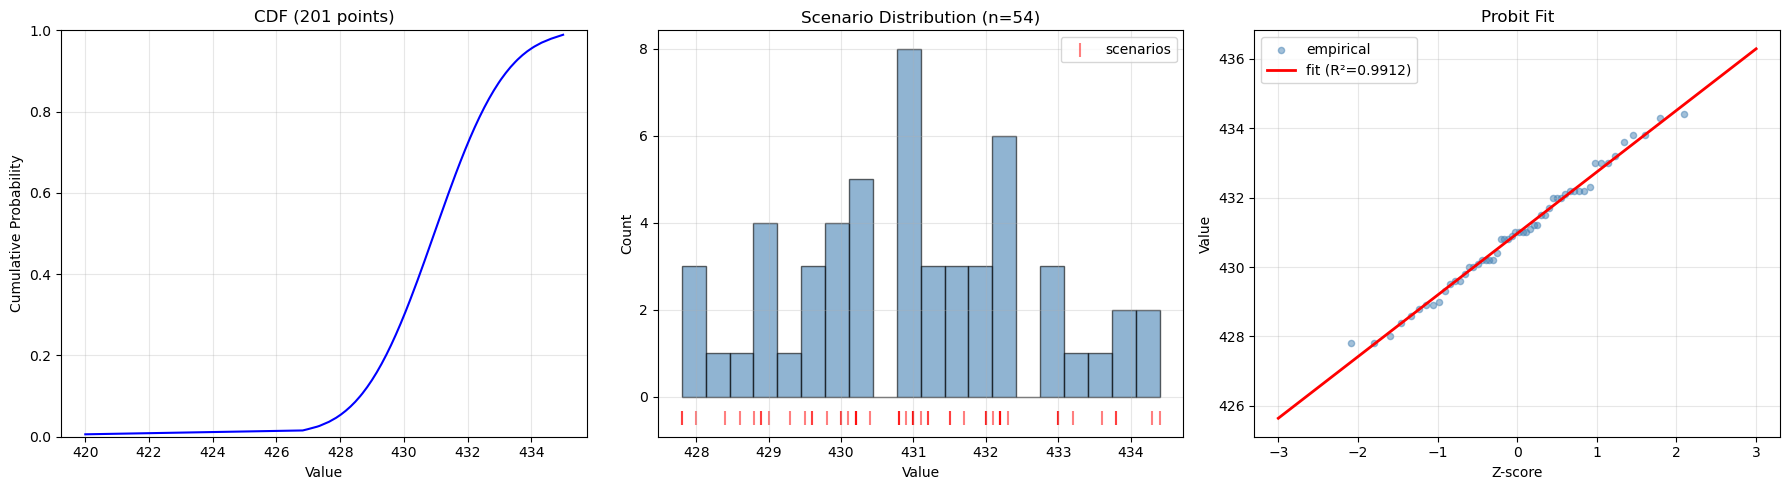


--- Summary Statistics ---
  p5: 428
  p25: 429.8
  p50: 431
  p75: 432.2
  p95: 433.9
  R²: 0.9912


In [10]:
# =====================================================
# CELL 12: Visualization
# =====================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- Subplot 1: CDF Curve ---
ax1 = axes[0]
ax1.plot(cdf_values, cdf_201, 'b-', linewidth=1.5)
ax1.set_xlabel('Value')
ax1.set_ylabel('Cumulative Probability')
ax1.set_title('CDF (201 points)')
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 1)

# --- Subplot 2: Scenario Distribution ---
ax2 = axes[1]
ax2.hist(validated_scenarios, bins=20, alpha=0.6, color='steelblue', edgecolor='black')
ax2.scatter(validated_scenarios, np.zeros(len(validated_scenarios)) - 0.5,
            marker='|', color='red', s=100, alpha=0.5, label='scenarios')
ax2.set_xlabel('Value')
ax2.set_ylabel('Count')
ax2.set_title(f'Scenario Distribution (n={len(validated_scenarios)})')
ax2.legend()
ax2.grid(True, alpha=0.3)

# --- Subplot 3: Probit Fit ---
ax3 = axes[2]
data_sorted = np.sort(np.array(validated_scenarios))
n = len(data_sorted)
empirical_pctl = np.array(range(1, n + 1)) / (n + 1)
empirical_z = _z_from_pcntl(empirical_pctl)
ax3.scatter(empirical_z, data_sorted, alpha=0.5, s=20, color='steelblue', label='empirical')
z_line = np.linspace(-3, 3, 100)
fit_line = z_line * slope + intercept
ax3.plot(z_line, fit_line, 'r-', linewidth=2, label=f'fit (R²={r_squared:.4f})')
ax3.set_xlabel('Z-score')
ax3.set_ylabel('Value')
ax3.set_title('Probit Fit')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- Summary Stats ---
p_indices = {5: 4, 25: 24, 50: 49, 75: 74, 95: 94}
print("\n--- Summary Statistics ---")
for label, idx in p_indices.items():
    print(f"  p{label}: {probit_pairs[idx][1]:.4g}")
print(f"  R²: {r_squared:.4f}")

In [11]:
# =====================================================
# CELL 13: LLM Reasoning Text
# =====================================================

for i, reasoning in enumerate(all_reasonings, 1):
    print(f"={'=' * 60}")
    print(f"RUN {i}/{len(all_reasonings)}  ({len(reasoning)} chars)")
    print(f"={'=' * 60}")
    print(reasoning)
    print()

RUN 1/6  (3372 chars)
Units for the answer are: parts per million (ppm) of CO2 (as reported by Mauna Loa monthly mean).

## Review some potential outcomes (for March 2026 monthly mean at Mauna Loa)
1. **Time left until the outcome is known:** about 3 to 4 weeks (March must finish; the monthly mean is typically finalized/published in early April).
2. **Outcome if nothing changed (the current value):** recent reporting cites Mauna Loa around **425 ppm in late October 2025**; adjusting for typical seasonality (Oct low → Mar higher) and baseline growth, early March 2026 would plausibly sit around the **high 428s to ~430 ppm**.
3. **Outcome if the current trend continued:** recent years have seen roughly **2.4 to 3.5 ppm/year** increases; carrying that forward implies March 2026 likely lands roughly **~428 to ~432 ppm** (seasonal cycle pushes spring months above the annual mean).
4. **Expectations of experts and markets:** WMO/NOAA-linked reporting highlights **record/near-record growth in 